# EC購買データを用いた顧客セグメント分析と再購入予測

## 分析目的

Online Retailデータを用いて、
1. RFM分析による顧客セグメンテーション
2. 90日以内の再購入予測
3. RFMセグメントと機械学習を組み合わせたターゲティング

を行う。

特に、RFMだけでは同一セグメントとなる顧客を
再購入予測によってさらに細分化できるか検証する。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Yu Gothic"

In [2]:
df = pd.read_csv(
    "../data/online_retail.csv",
    parse_dates=["InvoiceDate"]
)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.shape


(541909, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## <span style="color:green;">データの前処理</span>

In [7]:
df_clean = df.copy()

**欠損値処理**

In [8]:
print(df_clean['CustomerID'].isna().mean())

0.249266943342886


In [9]:
# CustomerIDの欠損値がある行は全体の約25パーセントを占めるが、分析に使えないため削除する。
df_clean = df_clean.dropna(subset=["CustomerID"])
# Descriptionに関しては、分析ではStockCodeを用いるため直接扱わない。そのため欠損値補完は行わない。
print(df_clean.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [10]:
# 上の結果より、Descriptionが欠損している行はすべてCustomerIDも同様に欠損していることが推測される。
df[df["Description"].isna()][
    ["Description", "CustomerID"]
].isna().sum()

Description    1454
CustomerID     1454
dtype: int64

In [11]:
# キャンセルされた取引を削除 
df_clean = df_clean[
    (~df_clean["InvoiceNo"].astype(str).str.startswith("C"))
    & (df_clean["Quantity"] > 0)
    & (df_clean["UnitPrice"] > 0)
]
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,397884.000000,397884,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023,3.116488,15294.423453
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,179.331775,NaN,22.097877,1713.141560


# <span style="color:green;">RFM分析</span>
Recency:最終購入日からの経過日数。  
Frequency:購入頻度。購入回数。  
Monetary:購入金額の総額。  

In [12]:
# 基準とする日付
basis_InvoiceDate = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

df_clean["TotalPrice"] = df_clean["Quantity"] * df_clean['UnitPrice']
# Recency,Frequency,MonetaryをCustomerIDごとに求める
recency = df_clean.groupby("CustomerID")["InvoiceDate"].max()
frequency = df_clean.groupby("CustomerID")["InvoiceNo"].nunique()
monetary = df_clean.groupby("CustomerID")["TotalPrice"].sum()

rfm = pd.DataFrame(
    {
        "Recency": (basis_InvoiceDate - recency).dt.days,
        "Frequency": frequency,
        "Monetary": monetary
    }
).reset_index()
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
...,...,...,...,...
4333,18280.0,278,1,180.60
4334,18281.0,181,1,80.82
4335,18282.0,8,2,178.05
4336,18283.0,4,16,2094.88


In [13]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


### ヒストグラムで表示

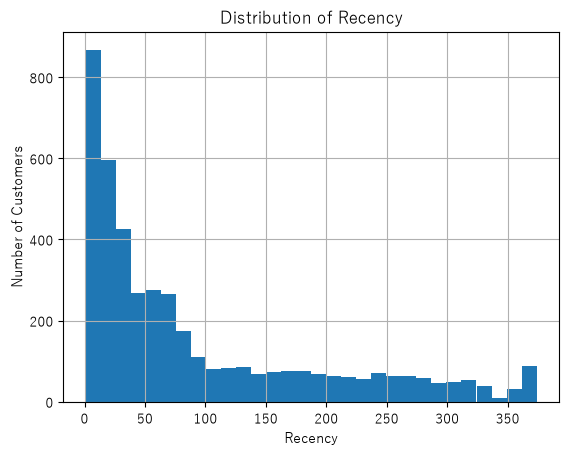

In [14]:
rfm["Recency"].hist(bins = 30)
plt.title("Distribution of Recency")
plt.xlabel("Recency")
plt.ylabel("Number of Customers")
plt.show()

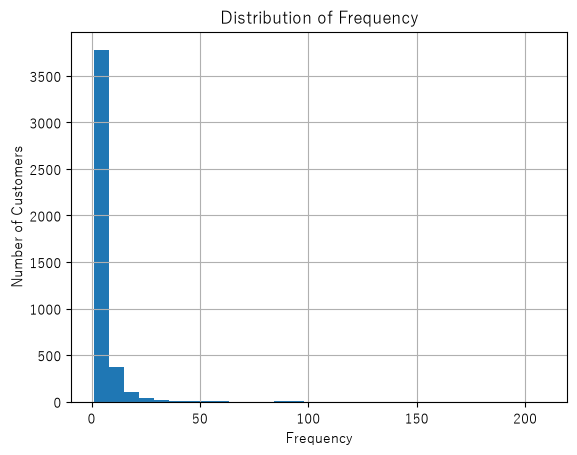

In [15]:
rfm["Frequency"].hist(bins = 30)
plt.title("Distribution of Frequency")
plt.xlabel("Frequency")
plt.ylabel("Number of Customers")
plt.show()

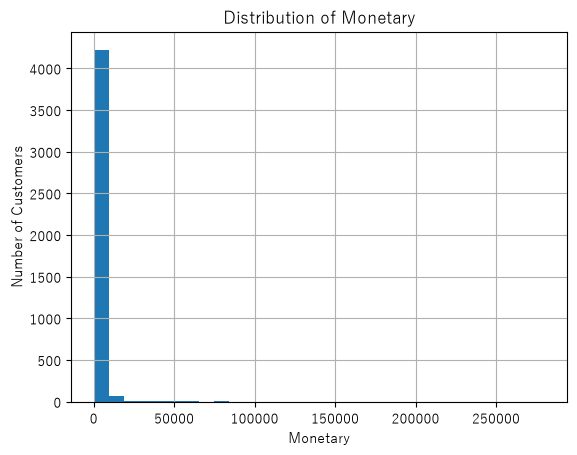

In [16]:
rfm["Monetary"].hist(bins=30)
plt.title("Distribution of Monetary")
plt.xlabel("Monetary")
plt.ylabel("Number of Customers")
plt.show()

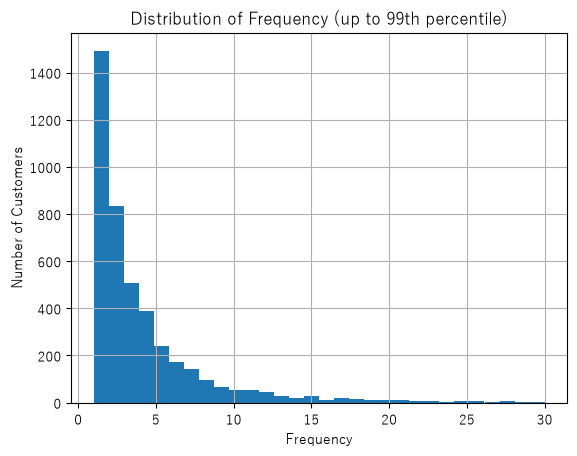

In [17]:
# わかりやすくするために上位1パーセントを除外
frequency_limit = rfm["Frequency"].quantile(0.99)
rfm[rfm["Frequency"] <= frequency_limit]["Frequency"].hist(bins = 30)
plt.title("Distribution of Frequency (up to 99th percentile)")
plt.xlabel("Frequency")
plt.ylabel("Number of Customers")
plt.show()

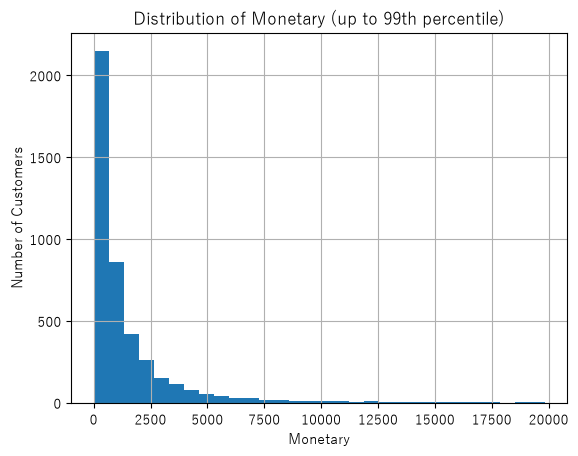

In [18]:
# わかりやすくするために上位1パーセントを除外
monetary_limit = rfm["Monetary"].quantile(0.99)

rfm[rfm["Monetary"] <= monetary_limit]["Monetary"].hist(bins=30)

plt.title("Distribution of Monetary (up to 99th percentile)")
plt.xlabel("Monetary")
plt.ylabel("Number of Customers")
plt.show()

In [19]:
# 次にスコアの割り当てを決める。
# データの分布が極端に偏っているため、cutメソッドではなく、qcutメソッドを使う
# Recencyのみ小さいほどいいためラベルが逆
rfm["R_score"] = pd.qcut(
    rfm["Recency"],
    3,
    labels=[3,2,1]
)
# 四分位数が重複しないようにrankメソッドで購入回数を順位に変換
rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    3,
    labels=[1,2,3]
)

rfm["M_score"] = pd.qcut(
    rfm["Monetary"],
    3,
    labels=[1,2,3]
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,12346.0,326,1,77183.60,1,1,3
1,12347.0,2,7,4310.00,3,3,3
2,12348.0,75,4,1797.24,2,2,3
3,12349.0,19,1,1757.55,3,1,3
4,12350.0,310,1,334.40,1,1,1


In [20]:
# 次に先ほどもとめたスコアを用いて９つのグループに分類する。セグメント名は参考にしたサイトから引用（仮）。
segment_map = {
    (3, 3): "優良",
    (3, 2): "優良候補",
    (3, 1): "新規",

    (2, 3): "警戒",
    (2, 2): "注意",
    (2, 1): "休眠傾向",

    (1, 3): "過去最良",
    (1, 2): "過去候補",
    (1, 1): "休眠"
}

In [21]:
def assign_segment(row):
    key = (
        int(row["R_score"]),
        int(row["F_score"])
    )
    return segment_map[key]


In [22]:
# 各顧客データを分類し列を追加
rfm["Segment"] = rfm.apply(
    assign_segment,
    axis=1
)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment
0,12346.0,326,1,77183.60,1,1,3,休眠
1,12347.0,2,7,4310.00,3,3,3,優良
2,12348.0,75,4,1797.24,2,2,3,注意
3,12349.0,19,1,1757.55,3,1,3,新規
4,12350.0,310,1,334.40,1,1,1,休眠


In [23]:
segment_count = rfm["Segment"].value_counts()
segment_count

Segment
優良      870
休眠      819
注意      531
過去候補    490
休眠傾向    458
警戒      440
優良候補    425
新規      169
過去最良    136
Name: count, dtype: int64

In [24]:
# セグメントごとの顧客比率(%)
segment_ratio = (
    rfm["Segment"].value_counts(normalize=True).mul(100).round(1)
)
segment_ratio

Segment
優良      20.1
休眠      18.9
注意      12.2
過去候補    11.3
休眠傾向    10.6
警戒      10.1
優良候補     9.8
新規       3.9
過去最良     3.1
Name: proportion, dtype: float64

In [25]:
# RスコアとFスコアのクロス集計表（%）
ratio_table = pd.crosstab(
    rfm["R_score"],
    rfm["F_score"],
    normalize="all"
) * 100

In [26]:
# クロス集計表の行と列の順序変更
ratio_table = ratio_table.reindex(
    index = [3,2,1],
    columns = [3,2,1]
)
ratio_table

F_score,3,2,1
R_score,,,
3,20.055325,9.797142,3.895805
2,10.142923,12.240664,10.557861
1,3.135085,11.295528,18.879668


In [27]:
# RスコアとFスコアでグループ分けし、Monetaryの平均でピボットテーブルを作る
monetary_table = pd.pivot_table(
    rfm,
    index="R_score",
    columns="F_score",
    values="Monetary",
    aggfunc="mean",
    observed=True
)

In [28]:
monetary_table = monetary_table.reindex(
    index=[3, 2, 1],
    columns=[3, 2, 1]
)

monetary_table

F_score,3,2,1
R_score,,,
3,6184.598862,1314.430612,324.564201
2,2688.958230,953.686744,424.474172
1,1726.564191,915.764900,427.138645


In [29]:
segment_name_table = [
    ["優良", "優良候補", "新規"],
    ["警戒", "注意", "休眠傾向"],
    ["過去最良", "過去候補", "休眠"]
]

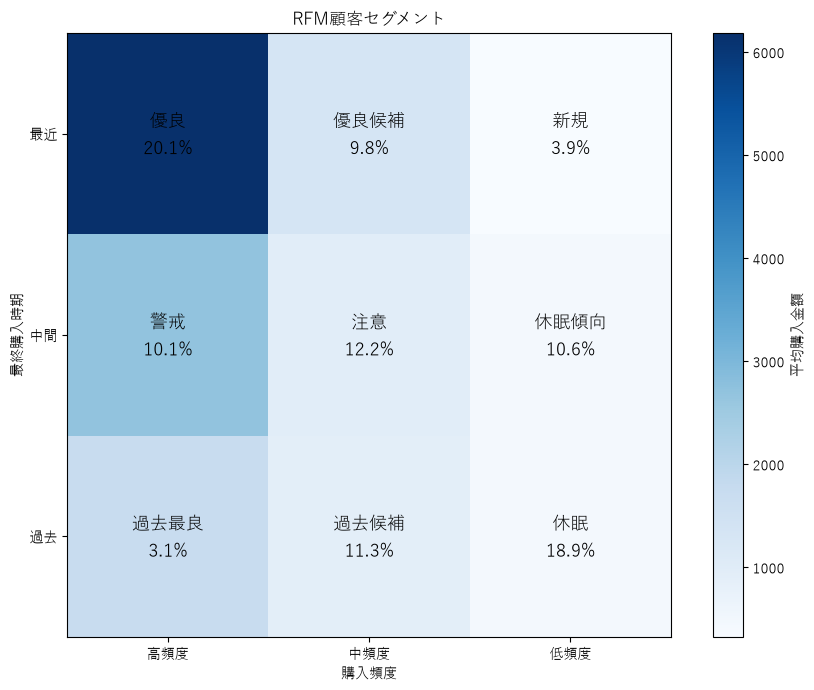

In [30]:
# ビジュアル化
fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(
    monetary_table.values,
    cmap = "Blues"
)

for i in range(3):
    for j in range(3):
        segment_name = segment_name_table[i][j]
        # ratio → セグメントごとの割合
        ratio = ratio_table.iloc[i, j]
        text = f"{segment_name}\n{ratio:.1f}%"
        # 第一引数：x座標、第二引数：y座標、第三引数：表示するテキスト、　第四引数＆第五引数：水平方向と垂直方向の表示位置、　第五引数：フォントサイズ
        ax.text(
            j,
            i,
            text,
            ha="center",
            va="center",
            fontsize = 13
        )

# 目盛り位置とそのラベルの指定
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(
    ["高頻度", "中頻度", "低頻度"]
)

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(
    ["最近", "中間", "過去"]
)

ax.set_xlabel("購入頻度")
ax.set_ylabel("最終購入時期")
ax.set_title("RFM顧客セグメント")

colorbar = plt.colorbar(
    image,
    ax=ax
)

colorbar.set_label("平均購入金額")

plt.tight_layout()
plt.show()

In [31]:
rfm

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment
0,12346.0,326,1,77183.60,1,1,3,休眠
1,12347.0,2,7,4310.00,3,3,3,優良
2,12348.0,75,4,1797.24,2,2,3,注意
3,12349.0,19,1,1757.55,3,1,3,新規
4,12350.0,310,1,334.40,1,1,1,休眠
...,...,...,...,...,...,...,...,...
4333,18280.0,278,1,180.60,1,2,1,過去候補
4334,18281.0,181,1,80.82,1,2,1,過去候補
4335,18282.0,8,2,178.05,3,2,1,優良候補
4336,18283.0,4,16,2094.88,3,3,3,優良


In [32]:
segment_summary = rfm.groupby("Segment", observed = True).agg(
    CustomerCount = ("CustomerID", "count"),
    RecencyMean = ("Recency", "mean"),
    RecencyMedian = ("Recency", "median"),
    FrequencyMean = ("Frequency", "mean"),
    FrequencyMedian = ("Frequency", "median"),
    MonetaryMean = ("Monetary", "mean"),
    MonetaryMedian = ("Monetary", "median")
).round(1)
segment_summary["Ratio"] = (segment_summary["CustomerCount"] / len(rfm) * 100).round(1)
segment_summary

,CustomerCount,RecencyMean,RecencyMedian,FrequencyMean,FrequencyMedian,MonetaryMean,MonetaryMedian,Ratio
Segment,,,,,,,,
休眠,819,241.8,247.0,1.0,1.0,427.1,238.8,18.9
休眠傾向,458,56.5,56.0,1.0,1.0,424.5,310.9,10.6
優良,870,10.2,9.0,11.5,7.0,6184.6,2550.8,20.1
優良候補,425,13.3,13.0,2.5,2.0,1314.4,656.7,9.8
新規,169,15.0,17.0,1.0,1.0,324.6,244.4,3.9
注意,531,53.2,51.0,2.4,2.0,953.7,689.9,12.2
警戒,440,47.9,43.0,6.6,5.0,2689.0,1996.4,10.1
過去候補,490,184.2,173.5,2.3,2.0,915.8,576.1,11.3
過去最良,136,153.3,129.5,5.5,5.0,1726.6,1262.8,3.1


In [33]:
# 「警戒」「注意」「過去最良」などセグメント名が分かりづらいため、集計結果をもとに修正 
segment_map_final = {
    (3, 3): "優良顧客",
    (3, 2): "優良候補",
    (3, 1): "新規顧客",

    (2, 3): "要フォロー",
    (2, 2): "継続停滞",
    (2, 1): "初回購入後停滞",

    (1, 3): "休眠優良顧客",
    (1, 2): "休眠顧客",
    (1, 1): "長期休眠顧客"
}
rfm["Segment"] = rfm.apply(
    lambda row: segment_map_final[
        (int(row["R_score"]), int(row["F_score"]))
    ],
    axis=1
)
rfm

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment
0,12346.0,326,1,77183.60,1,1,3,長期休眠顧客
1,12347.0,2,7,4310.00,3,3,3,優良顧客
2,12348.0,75,4,1797.24,2,2,3,継続停滞
3,12349.0,19,1,1757.55,3,1,3,新規顧客
4,12350.0,310,1,334.40,1,1,1,長期休眠顧客
...,...,...,...,...,...,...,...,...
4333,18280.0,278,1,180.60,1,2,1,休眠顧客
4334,18281.0,181,1,80.82,1,2,1,休眠顧客
4335,18282.0,8,2,178.05,3,2,1,優良候補
4336,18283.0,4,16,2094.88,3,3,3,優良顧客


**※ 補足**  
Monetaryまで分類軸に加えると27セグメントとなり解釈が複雑になるため、本分析ではR×Fの9セグメントを採用した。Monetaryは各セグメントの顧客価値を確認する指標として利用した。

# セグメント別施策提案

優良顧客：新製品体験イベントへの招待  
優良候補：新製品情報メール  
新規顧客：2回目利用クーポン  
要フォロー：メルマガ登録  
継続停滞：継続的にメール送信  
初回購入後停滞：再購入リマインド  
休眠優良顧客：離れた原因の分析  
休眠顧客：復帰割引  
長期休眠顧客：新規グループへの施策見直し  

# <span style="color:green;">再購入予測</span>

### 〇目的  
基準日までの購買履歴を使って、その後約90日以内に顧客が再購入するかを予測する。  
### 〇目的変数  
1:基準日後、90日以内に購入した
0:基準日後、90日以内に購入しなかった

In [34]:
print(df_clean["InvoiceDate"].min())
print(df_clean["InvoiceDate"].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


基準日を、データの最後の購入日から90日前とする。

In [35]:
prediction_days = 90
# normalizeで時刻を00:00:00にそろえる
data_end = df_clean["InvoiceDate"].max().normalize()
cutoff_date = data_end - pd.Timedelta(days=prediction_days)
print("基準日:", cutoff_date)
print("予測機関終了日:", data_end)

基準日: 2011-09-10 00:00:00
予測機関終了日: 2011-12-09 00:00:00


基準日以降を再購入したかの判定につかう

In [36]:
observation_df = df_clean[df_clean["InvoiceDate"] < cutoff_date].copy()

prediction_df = df_clean[df_clean["InvoiceDate"] >= cutoff_date].copy()

In [37]:
print(
    "特徴量を作成する期間:",
    observation_df["InvoiceDate"].min(),
    "～",
    observation_df["InvoiceDate"].max()
)

print(
    "再購入判定の期間:",
    prediction_df["InvoiceDate"].min(),
    "～",
    prediction_df["InvoiceDate"].max()
)

特徴量を作成する期間: 2010-12-01 08:26:00 ～ 2011-09-09 15:53:00
再購入判定の期間: 2011-09-11 10:35:00 ～ 2011-12-09 12:50:00


### 基準日以前のデータでRFMを作る

In [38]:
# 最終購入日
last_purchase_date = (observation_df.groupby("CustomerID")["InvoiceDate"].max())
last_purchase_date

CustomerID
12346.0   2011-01-18 10:01:00
12347.0   2011-08-02 08:48:00
12348.0   2011-04-05 10:47:00
12350.0   2011-02-02 16:01:00
12352.0   2011-03-22 16:08:00
                  ...        
18280.0   2011-03-07 09:52:00
18281.0   2011-06-12 10:53:00
18282.0   2011-08-05 13:35:00
18283.0   2011-09-05 12:35:00
18287.0   2011-05-22 10:39:00
Name: InvoiceDate, Length: 3370, dtype: datetime64[us]

In [39]:
# Frequency
frequency = (observation_df.groupby("CustomerID")["InvoiceNo"].nunique())
# Monetary
monetary = (observation_df.groupby("CustomerID")["TotalPrice"].sum())

In [40]:
model_df = pd.DataFrame({
    "Recency": (cutoff_date - last_purchase_date).dt.days,
    "Frequency": frequency,
    "Monetary": monetary
}).reset_index()

In [41]:
model_df.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,234,1,77183.60
1,12347.0,38,5,2790.86
2,12348.0,157,3,1487.24
3,12350.0,219,1,334.40
4,12352.0,171,5,1561.81


In [42]:
# 再購入した顧客のIDを集計
repurchased_customers = (
    prediction_df["CustomerID"]
    .dropna()
    .unique()
)

In [43]:
# 再購入した顧客には1、していない顧客には0となるようなラベルを追加
model_df["Repurchased"] = (
    model_df["CustomerID"].isin(repurchased_customers).astype(int)
)

In [44]:
model_df["Repurchased"].value_counts()

Repurchased
1    1921
0    1449
Name: count, dtype: int64

In [45]:
repurchase_ratio = (
    model_df["Repurchased"].value_counts(normalize=True).mul(100).round(1)
)
repurchase_ratio

Repurchased
1    57.0
0    43.0
Name: proportion, dtype: float64

In [46]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3370 entries, 0 to 3369
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CustomerID   3370 non-null   float64
 1   Recency      3370 non-null   int64  
 2   Frequency    3370 non-null   int64  
 3   Monetary     3370 non-null   float64
 4   Repurchased  3370 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 131.8 KB


In [47]:
model_df.isna().sum()

CustomerID     0
Recency        0
Frequency      0
Monetary       0
Repurchased    0
dtype: int64

In [48]:
model_df.describe()

,CustomerID,Recency,Frequency,Monetary,Repurchased
count,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000
mean,15276.122849,93.998220,3.532938,1618.814594,0.570030
std,1725.580817,79.991369,5.788414,6151.394333,0.495145
min,12346.000000,0.000000,1.000000,2.900000,0.000000
25%,13786.250000,25.000000,1.000000,266.100000,0.000000
50%,15234.500000,73.000000,2.000000,565.960000,1.000000
75%,16765.750000,150.750000,4.000000,1388.937500,1.000000
max,18287.000000,282.000000,132.000000,178302.620000,1.000000


In [49]:
model_df.groupby("Repurchased")[
    ["Recency", "Frequency", "Monetary"]
].mean().round(1)

,Recency,Frequency,Monetary
Repurchased,,,
0,122.1,1.9,714.5
1,72.8,4.8,2301.0


In [50]:
model_df.groupby("Repurchased")[
    ["Recency", "Frequency", "Monetary"]
].median().round(1)

,Recency,Frequency,Monetary
Repurchased,,,
0,113.0,1.0,349.6
1,49.0,3.0,874.9


### RFMについて再購入の有無で可視化する

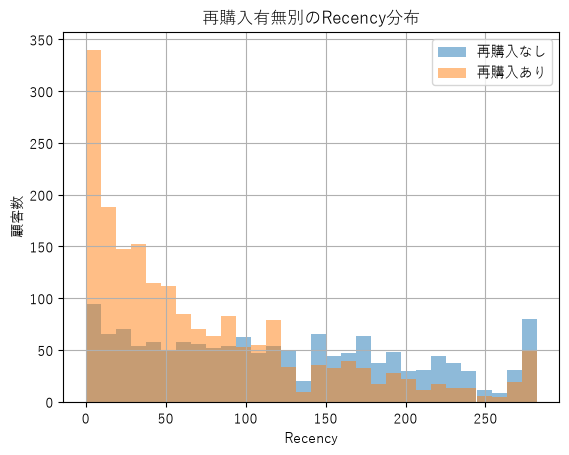

In [51]:
model_df[
    model_df["Repurchased"] == 0
]["Recency"].hist(
    bins=30,
    alpha=0.5,
    label="再購入なし"
)

model_df[
    model_df["Repurchased"] == 1
]["Recency"].hist(
    bins=30,
    alpha=0.5,
    label="再購入あり"
)

plt.xlabel("Recency")
plt.ylabel("顧客数")
plt.title("再購入有無別のRecency分布")
plt.legend()
plt.show()

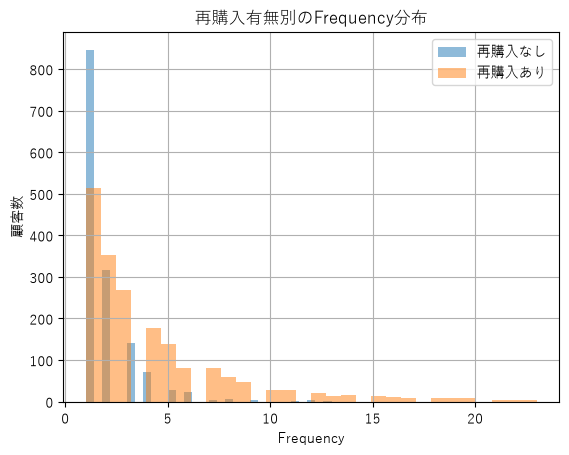

In [52]:
frequency_limit = model_df["Frequency"].quantile(0.99)

model_df[
    (model_df["Repurchased"] == 0) & (model_df["Frequency"] <= frequency_limit)
]["Frequency"].hist(
    bins=30,
    alpha=0.5,
    label="再購入なし"
)

model_df[
    (model_df["Repurchased"] == 1) & (model_df["Frequency"] <= frequency_limit)
]["Frequency"].hist(
    bins=30,
    alpha=0.5,
    label="再購入あり"
)

plt.xlabel("Frequency")
plt.ylabel("顧客数")
plt.title("再購入有無別のFrequency分布")
plt.legend()
plt.show()

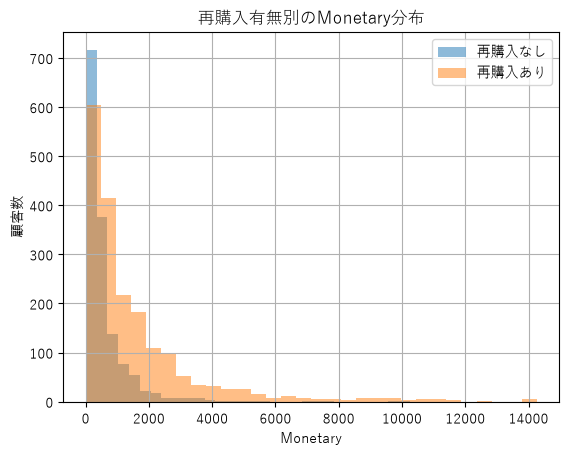

In [53]:
monetary_limit = model_df["Monetary"].quantile(0.99)

model_df[
    (model_df["Repurchased"] == 0) & (model_df["Monetary"] <= monetary_limit)
]["Monetary"].hist(
    bins=30,
    alpha=0.5,
    label="再購入なし"
)

model_df[
    (model_df["Repurchased"] == 1) & (model_df["Monetary"] <= monetary_limit)
]["Monetary"].hist(
    bins=30,
    alpha=0.5,
    label="再購入あり"
)

plt.xlabel("Monetary")
plt.ylabel("顧客数")
plt.title("再購入有無別のMonetary分布")
plt.legend()
plt.show()

### 説明変数xと目的変数yを作る

In [54]:
x = model_df[["Recency", "Frequency", "Monetary"]]

y = model_df["Repurchased"]

### 学習用データとテスト用データに分ける

In [55]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=22, stratify=y)

In [56]:
print("全体")
print(y.value_counts(normalize=True))

print("\n学習データ")
print(y_train.value_counts(normalize=True))

print("\nテストデータ")
print(y_test.value_counts(normalize=True))

全体
Repurchased
1    0.57003
0    0.42997
Name: proportion, dtype: float64

学習データ
Repurchased
1    0.570104
0    0.429896
Name: proportion, dtype: float64

テストデータ
Repurchased
1    0.569733
0    0.430267
Name: proportion, dtype: float64


### ベースラインの作成

In [57]:
from sklearn.dummy import DummyClassifier
dummy_model = DummyClassifier(strategy = "most_frequent")
dummy_model.fit(x_train, y_train)
dummy_accuracy = dummy_model.score(x_test,y_test)
print(dummy_accuracy)

0.56973293768546


### ロジスティクス回帰

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000
    ))
])

In [59]:
import sklearn
sklearn.set_config(display="text")

logistic_model.fit(x_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [60]:
y_pred = logistic_model.predict(x_test)
y_pred

array([0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1,

In [61]:
y_proba = logistic_model.predict_proba(x_test)[:, 1]
y_proba

array([0.49626772, 0.44813152, 0.50208015, 0.58732951, 0.53060937,
       0.49720295, 0.99864935, 0.3087126 , 0.38634759, 0.52782294,
       0.59179416, 0.58460533, 0.57590366, 0.48266952, 0.69490906,
       0.93418846, 0.61049689, 0.45973912, 0.31038588, 0.69238724,
       0.6100059 , 0.55818041, 0.4913021 , 0.99340423, 0.35243201,
       0.54967746, 0.61510794, 0.53494591, 0.67781802, 0.82600954,
       0.79492092, 0.545431  , 0.50772188, 0.52875933, 0.44445839,
       0.36411305, 0.46425033, 0.73490765, 0.79915182, 0.37389895,
       0.41579188, 0.34650661, 0.59731972, 0.61160535, 0.95328707,
       0.38760448, 0.93023919, 0.56481243, 0.38430658, 0.80399245,
       0.78946574, 0.4223474 , 0.8411899 , 0.93885715, 0.79832818,
       0.51803853, 0.32054151, 0.49756272, 0.3931612 , 0.67423106,
       0.37406212, 0.44741214, 0.68112302, 0.34457386, 0.53922313,
       0.50327428, 0.41138998, 0.67093324, 0.80461513, 0.37752197,
       0.33549785, 0.40921593, 0.52354925, 0.46609863, 0.76489

In [62]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1:", f1_score(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.6824925816023739
Precision: 0.7190721649484536
Recall: 0.7265625
F1: 0.7227979274611399
ROC-AUC: 0.7428969109195402


In [63]:
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

[[181 109]
 [105 279]]


In [64]:
logistic = logistic_model.named_steps["model"]
coefficients = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": logistic.coef_[0]
})
coefficients

,Feature,Coefficient
0,Recency,-0.312013
1,Frequency,1.861480
2,Monetary,-0.045739


In [65]:
model_df["Frequency_log"] = np.log1p(model_df["Frequency"])
model_df["Monetary_log"] = np.log1p(model_df["Monetary"])

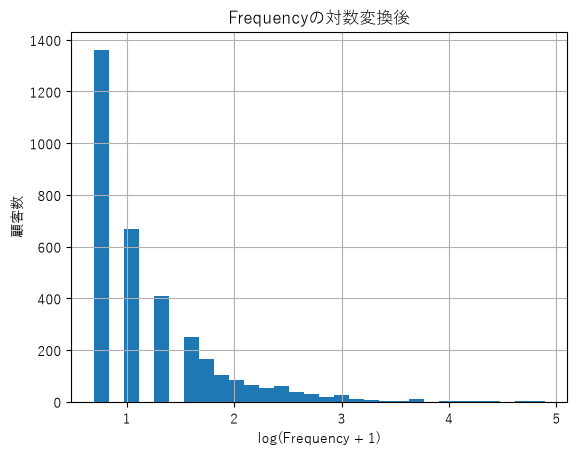

In [66]:
model_df["Frequency_log"].hist(
    bins=30
)

plt.xlabel("log(Frequency + 1)")
plt.ylabel("顧客数")
plt.title("Frequencyの対数変換後")
plt.show()

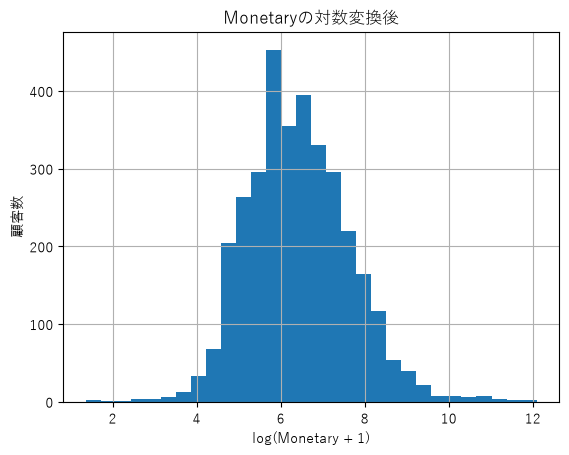

In [67]:
model_df["Monetary_log"].hist(
    bins=30
)

plt.xlabel("log(Monetary + 1)")
plt.ylabel("顧客数")
plt.title("Monetaryの対数変換後")
plt.show()

In [68]:
x_log = model_df[
    [
        "Recency",
        "Frequency_log",
        "Monetary_log"
    ]
]

y = model_df["Repurchased"]

In [69]:
x_log_train, x_log_test, y_log_train, y_log_test = train_test_split(
    x_log,
    y,
    test_size=0.2,
    random_state=22,
    stratify=y
)

In [70]:
logistic_log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000
    ))
])

logistic_log_model.fit(
    x_log_train,
    y_log_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [71]:
y_log_pred = logistic_log_model.predict(
    x_log_test
)

y_log_proba = logistic_log_model.predict_proba(
    x_log_test
)[:, 1]

In [72]:
print(
    "Accuracy:",
    accuracy_score(y_log_test, y_log_pred)
)

print(
    "Precision:",
    precision_score(y_log_test, y_log_pred)
)

print(
    "Recall:",
    recall_score(y_log_test, y_log_pred)
)

print(
    "F1:",
    f1_score(y_log_test, y_log_pred)
)

print(
    "ROC-AUC:",
    roc_auc_score(y_log_test, y_log_proba)
)

Accuracy: 0.6810089020771514
Precision: 0.720626631853786
Recall: 0.71875
F1: 0.7196870925684485
ROC-AUC: 0.7479885057471265


| モデル | Accuracy | Precision | Recall | F1 | ROC-AUC|
|---------|---------|----------|--------|-----|-------|
| Dummy | 0.570 | - | - | - | - |
| Logistic | 0.682 | 0.719  | 0.727 | 0.723 | 0.743 |
| Logistic(log変換) | 0.681 | 0.721 | 0.719 | 0.720 | 0.748 |

In [73]:
model_df[
    ["Recency", "Frequency", "Monetary"]
].corr().round(3)

,Recency,Frequency,Monetary
Recency,1.000,-0.322,-0.162
Frequency,-0.322,1.000,0.547
Monetary,-0.162,0.547,1.000


In [74]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=22
)
rf_model.fit(x_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=22)

In [75]:
rf_pred = rf_model.predict(x_test)
rf_proba = rf_model.predict_proba(x_test)[:, 1]

In [76]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_proba)

print("Accuracy :", round(rf_accuracy, 3))
print("Precision:", round(rf_precision, 3))
print("Recall   :", round(rf_recall, 3))
print("F1       :", round(rf_f1, 3))
print("ROC-AUC  :", round(rf_roc_auc, 3))

Accuracy : 0.687
Precision: 0.719
Recall   : 0.74
F1       : 0.729
ROC-AUC  : 0.737


| モデル | Accuracy | Precision | Recall | F1 | ROC-AUC|
|---------|---------|----------|--------|-----|-------|
| Dummy | 0.570 | - | - | - | - |
| Logistic | 0.682 | 0.719  | 0.727 | 0.723 | 0.743 |
| Logistic(log変換) | 0.681 | 0.721 | 0.719 | 0.720 | 0.748 |
| Random Forest | 0.687 | 0.719 | 0.740 | 0.729 | 0.737 |

In [77]:
feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)
feature_importance

,Feature,Importance
2,Monetary,0.511551
0,Recency,0.383588
1,Frequency,0.104860


In [78]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_model,
    x_test,
    y_test,
    scoring="roc_auc",
    n_repeats=30,
    random_state=22
)

permutation_df = pd.DataFrame({
    "Feature": x.columns,
    "ImportanceMean": perm_result.importances_mean,
    "ImportanceStd": perm_result.importances_std
}).sort_values(
    "ImportanceMean",
    ascending=False
)

permutation_df

,Feature,ImportanceMean,ImportanceStd
1,Frequency,0.129443,0.011407
0,Recency,0.112026,0.017739
2,Monetary,0.077730,0.013360


### 評価指標のまとめ
〇RFMの単純集計  
再購入者はRecencyが短い、Frequencyが高い、Monetaryが高い傾向にある。  
〇Logistic Regression  
Frequencyが強い正の関連がある。  
Recencyは負の関連がある。  
Monetaryは影響は小さい  
〇Random ForestのMDI  
Monetaryが最重要。MDIが適切ではない可能性がある。  
〇Random ForestのPermutation Importance  
Frequency > Recency > Monetary  
これはLogistic Regressionと比較的整合した結果となった。  

### 評価指標の考察  
Random Forestの不純度ベースの特徴量重要度ではMonetaryが最も高い値となった。一方、この指標は値の種類が多い連続変数を高く評価する場合があるため、Permutation Importanceを用いて追加検証を行った。その結果、Frequencyが0.129、Recencyが0.112、Monetaryが0.078となり、FrequencyとRecencyが再購入予測に特に寄与していることが確認された。この結果は、Frequencyが強い正の係数、Recencyが負の係数となったロジスティック回帰の結果とも概ね整合している。

In [79]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=22)


In [80]:
scoring = {
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1",
    "ROC-AUC": "roc_auc"
}

In [81]:
from sklearn.model_selection import cross_validate

logistic_cv = cross_validate(
    logistic_model,
    x,
    y,
    cv=cv,
    scoring=scoring
)

In [82]:
print(
    "Accuracy:",
    logistic_cv["test_Accuracy"].mean().round(3)
)

print(
    "Precision:",
    logistic_cv["test_Precision"].mean().round(3)
)

print(
    "Recall:",
    logistic_cv["test_Recall"].mean().round(3)
)

print(
    "F1:",
    logistic_cv["test_F1"].mean().round(3)
)

print(
    "ROC-AUC:",
    logistic_cv["test_ROC-AUC"].mean().round(3)
)

Accuracy: 0.672
Precision: 0.712
Recall: 0.713
F1: 0.712
ROC-AUC: 0.736


In [83]:
print(
    "ROC-AUC:",
    logistic_cv["test_ROC-AUC"].mean().round(3),
    "±",
    logistic_cv["test_ROC-AUC"].std().round(3)
)

ROC-AUC: 0.736 ± 0.012


In [84]:
rf_cv = cross_validate(
    rf_model,
    x,
    y,
    cv=cv,
    scoring=scoring
)

In [85]:
print(
    "Random Forest ROC-AUC:",
    rf_cv["test_ROC-AUC"].mean().round(3),
    "±",
    rf_cv["test_ROC-AUC"].std().round(3)
)

Random Forest ROC-AUC: 0.702 ± 0.017


In [86]:
logistic_log_cv = cross_validate(
    logistic_log_model,
    x_log,
    y,
    cv=cv,
    scoring=scoring
)

In [87]:
cv_result_table = pd.DataFrame({
    "Model": [
        "Logistic",
        "Logistic(log)",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_cv["test_Accuracy"].mean(),
        logistic_log_cv["test_Accuracy"].mean(),
        rf_cv["test_Accuracy"].mean()
    ],

    "Precision": [
        logistic_cv["test_Precision"].mean(),
        logistic_log_cv["test_Precision"].mean(),
        rf_cv["test_Precision"].mean()
    ],

    "Recall": [
        logistic_cv["test_Recall"].mean(),
        logistic_log_cv["test_Recall"].mean(),
        rf_cv["test_Recall"].mean()
    ],

    "F1": [
        logistic_cv["test_F1"].mean(),
        logistic_log_cv["test_F1"].mean(),
        rf_cv["test_F1"].mean()
    ],

    "ROC-AUC": [
        logistic_cv["test_ROC-AUC"].mean(),
        logistic_log_cv["test_ROC-AUC"].mean(),
        rf_cv["test_ROC-AUC"].mean()
    ],

    "ROC-AUC Std": [
        logistic_cv["test_ROC-AUC"].std(),
        logistic_log_cv["test_ROC-AUC"].std(),
        rf_cv["test_ROC-AUC"].std()
    ]
})

cv_result_table.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,ROC-AUC Std
0,Logistic,0.672,0.712,0.713,0.712,0.736,0.012
1,Logistic(log),0.677,0.718,0.715,0.716,0.739,0.012
2,Random Forest,0.646,0.688,0.695,0.691,0.702,0.017


# 特徴量エンジニアリング

In [88]:
# その顧客が何種類の商品を購入したか
unique_products = (
    observation_df
    .groupby("CustomerID")["StockCode"]
    .nunique()
)

In [89]:
# 顧客が何日購入したか
observation_df = observation_df.copy()
observation_df["PurchaseDays"] = (observation_df["InvoiceDate"].dt.date)
purchase_days = (
    observation_df
    .groupby("CustomerID")["PurchaseDays"]
    .nunique()
)

In [90]:
# 初回購入から基準日まで何日経過しているか
first_purchase_date = (
    observation_df
    .groupby("CustomerID")["InvoiceDate"]
    .min()
)
customer_age = (
    cutoff_date - first_purchase_date
).dt.days

In [91]:
# 特徴量をデータフレームに追加する
additional_features = pd.DataFrame({
    "UniqueProducts":unique_products,
    "PurchaseDays":purchase_days,
    "CustomerAge":customer_age
}
).reset_index()

In [92]:
model_df_extended = model_df.merge(
    additional_features,
    on="CustomerID",
    how="left"
)
model_df_extended["AvgOrderValue"] = (
    model_df_extended["Monetary"] / model_df_extended["Frequency"]
)

model_df_extended.head()

,CustomerID,Recency,Frequency,Monetary,Repurchased,Frequency_log,Monetary_log,UniqueProducts,PurchaseDays,CustomerAge,AvgOrderValue
0,12346.0,234,1,77183.60,0,0.693147,11.253955,1,1,234,77183.600000
1,12347.0,38,5,2790.86,1,1.791759,7.934463,82,5,276,558.172000
2,12348.0,157,3,1487.24,1,1.386294,7.305349,22,3,267,495.746667
3,12350.0,219,1,334.40,0,0.693147,5.815324,17,1,219,334.400000
4,12352.0,171,5,1561.81,1,1.791759,7.354241,26,4,205,312.362000


In [93]:
model_df_extended.info()

<class 'pandas.DataFrame'>
RangeIndex: 3370 entries, 0 to 3369
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CustomerID      3370 non-null   float64
 1   Recency         3370 non-null   int64  
 2   Frequency       3370 non-null   int64  
 3   Monetary        3370 non-null   float64
 4   Repurchased     3370 non-null   int64  
 5   Frequency_log   3370 non-null   float64
 6   Monetary_log    3370 non-null   float64
 7   UniqueProducts  3370 non-null   int64  
 8   PurchaseDays    3370 non-null   int64  
 9   CustomerAge     3370 non-null   int64  
 10  AvgOrderValue   3370 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 289.7 KB


In [94]:
model_df_extended[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "UniqueProducts",
        "PurchaseDays",
        "CustomerAge",
        "AvgOrderValue"
    ]
].describe()

,Recency,Frequency,Monetary,UniqueProducts,PurchaseDays,CustomerAge,AvgOrderValue
count,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000
mean,93.998220,3.532938,1618.814594,49.932344,3.206825,181.903264,398.486264
std,79.991369,5.788414,6151.394333,67.550890,4.626791,80.455546,1422.696074
min,0.000000,1.000000,2.900000,1.000000,1.000000,0.000000,2.900000
25%,25.000000,1.000000,266.100000,14.000000,1.000000,122.000000,169.577500
50%,73.000000,2.000000,565.960000,29.000000,2.000000,192.000000,284.140000
75%,150.750000,4.000000,1388.937500,63.000000,4.000000,264.000000,414.923125
max,282.000000,132.000000,178302.620000,1230.000000,83.000000,282.000000,77183.600000


In [95]:
model_df_extended.groupby("Repurchased")[
    [
        "UniqueProducts",
        "PurchaseDays",
        "CustomerAge",
        "AvgOrderValue"
    ]
].mean().round(1)

,UniqueProducts,PurchaseDays,CustomerAge,AvgOrderValue
Repurchased,,,,
0,29.2,1.7,169.1,401.6
1,65.6,4.3,191.6,396.1


In [96]:
model_df_extended.groupby("Repurchased")[
    [
        "UniqueProducts",
        "PurchaseDays",
        "CustomerAge",
        "AvgOrderValue"
    ]
].median().round(1)

,UniqueProducts,PurchaseDays,CustomerAge,AvgOrderValue
Repurchased,,,,
0,20.0,1.0,175.0,247.9
1,42.0,3.0,206.0,302.4


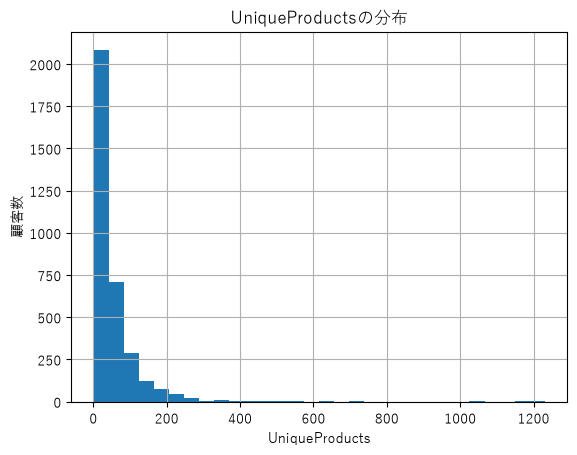

In [97]:
model_df_extended["UniqueProducts"].hist(
    bins=30
)

plt.xlabel("UniqueProducts")
plt.ylabel("顧客数")
plt.title("UniqueProductsの分布")
plt.show()

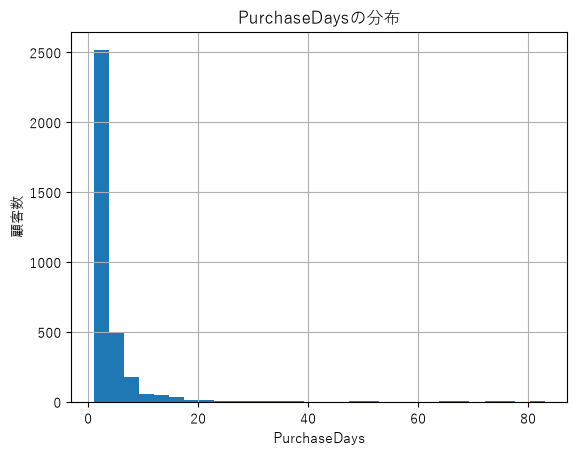

In [98]:
model_df_extended["PurchaseDays"].hist(
    bins=30
)

plt.xlabel("PurchaseDays")
plt.ylabel("顧客数")
plt.title("PurchaseDaysの分布")
plt.show()

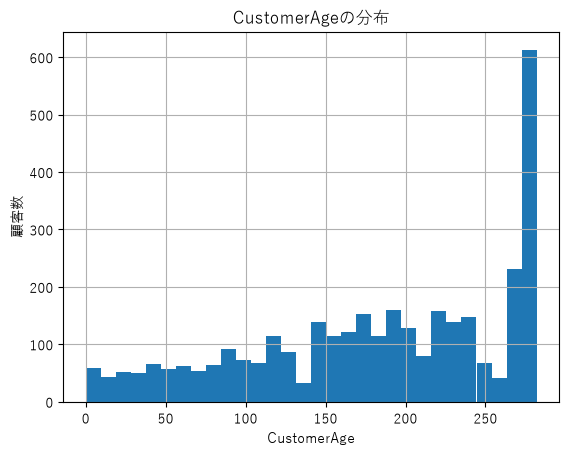

In [99]:
model_df_extended["CustomerAge"].hist(
    bins=30
)

plt.xlabel("CustomerAge")
plt.ylabel("顧客数")
plt.title("CustomerAgeの分布")
plt.show()

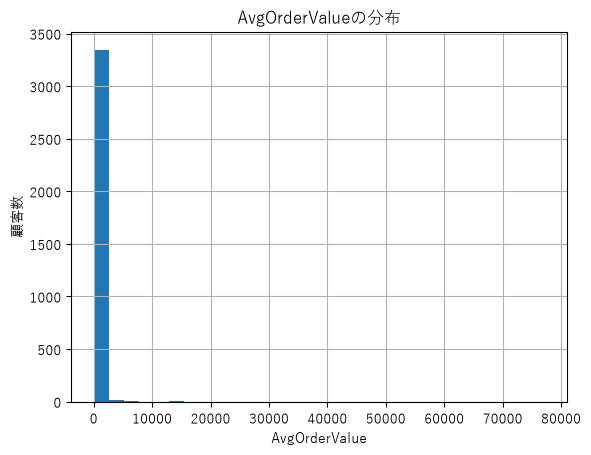

In [100]:
model_df_extended["AvgOrderValue"].hist(
    bins=30
)

plt.xlabel("AvgOrderValue")
plt.ylabel("顧客数")
plt.title("AvgOrderValueの分布")
plt.show()

In [101]:
feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "UniqueProducts",
    "PurchaseDays",
    "CustomerAge",
    "AvgOrderValue"
]

model_df_extended[
    feature_columns
].corr().round(2)

,Recency,Frequency,Monetary,UniqueProducts,PurchaseDays,CustomerAge,AvgOrderValue
Recency,1.00,-0.32,-0.16,-0.31,-0.36,0.29,0.00
Frequency,-0.32,1.00,0.55,0.70,0.97,0.32,0.03
Monetary,-0.16,0.55,1.00,0.42,0.51,0.16,0.38
UniqueProducts,-0.31,0.70,0.42,1.00,0.70,0.28,0.06
PurchaseDays,-0.36,0.97,0.51,0.70,1.00,0.34,0.02
CustomerAge,0.29,0.32,0.16,0.28,0.34,1.00,0.01
AvgOrderValue,0.00,0.03,0.38,0.06,0.02,0.01,1.00


In [102]:
x_extended = model_df_extended[
    feature_columns
]

y_extended = model_df_extended[
    "Repurchased"
]

In [103]:
extended_logistic_cv = cross_validate(
    logistic_model,
    x_extended,
    y_extended,
    cv=cv,
    scoring=scoring
)

In [104]:
print(
    "Accuracy:",
    extended_logistic_cv["test_Accuracy"].mean().round(3)
)

print(
    "Precision:",
    extended_logistic_cv["test_Precision"].mean().round(3)
)

print(
    "Recall:",
    extended_logistic_cv["test_Recall"].mean().round(3)
)

print(
    "F1:",
    extended_logistic_cv["test_F1"].mean().round(3)
)

print(
    "ROC-AUC:",
    extended_logistic_cv["test_ROC-AUC"].mean().round(3)
)

Accuracy: 0.68
Precision: 0.733
Recall: 0.691
F1: 0.711
ROC-AUC: 0.744


In [105]:
model_df_extended["Frequency_log"] = np.log1p(
    model_df_extended["Frequency"]
)

model_df_extended["Monetary_log"] = np.log1p(
    model_df_extended["Monetary"]
)

model_df_extended["UniqueProducts_log"] = np.log1p(
    model_df_extended["UniqueProducts"]
)

model_df_extended["PurchaseDays_log"] = np.log1p(
    model_df_extended["PurchaseDays"]
)

model_df_extended["AvgOrderValue_log"] = np.log1p(
    model_df_extended["AvgOrderValue"]
)

In [106]:
extended_log_features = [
    "Recency",
    "Frequency_log",
    "Monetary_log",
    "UniqueProducts_log",
    "PurchaseDays_log",
    "CustomerAge",
    "AvgOrderValue_log"
]

x_extended_log = model_df_extended[
    extended_log_features
]

In [107]:
extended_log_cv = cross_validate(
    logistic_model,
    x_extended_log,
    y_extended,
    cv=cv,
    scoring=scoring
)

In [108]:
print(
    "Accuracy:",
    extended_log_cv["test_Accuracy"].mean().round(3)
)

print(
    "Precision:",
    extended_log_cv["test_Precision"].mean().round(3)
)

print(
    "Recall:",
    extended_log_cv["test_Recall"].mean().round(3)
)

print(
    "F1:",
    extended_log_cv["test_F1"].mean().round(3)
)

print(
    "ROC-AUC:",
    extended_log_cv["test_ROC-AUC"].mean().round(3)
)

Accuracy: 0.682
Precision: 0.725
Recall: 0.713
F1: 0.719
ROC-AUC: 0.746


In [109]:
base_features = [
    "Recency",
    "Frequency_log",
    "Monetary_log"
]

In [110]:
features_unique = base_features + [
    "UniqueProducts_log"
]

In [111]:
features_days = base_features + [
    "PurchaseDays_log"
]

In [112]:
features_age = base_features + [
    "CustomerAge"
]

In [113]:
features_aov = base_features + [
    "AvgOrderValue_log"
]

In [114]:
def evaluate_features(features):
    X_temp = model_df_extended[features]

    result = cross_validate(
        logistic_model,
        X_temp,
        y_extended,
        cv=cv,
        scoring=scoring
    )

    return {
        "Accuracy": result["test_Accuracy"].mean(),
        "Precision": result["test_Precision"].mean(),
        "Recall": result["test_Recall"].mean(),
        "F1": result["test_F1"].mean(),
        "ROC-AUC": result["test_ROC-AUC"].mean()
    }

In [115]:
feature_test_results = pd.DataFrame({
    "RFM(log)": evaluate_features(
        base_features
    ),

    "+ UniqueProducts": evaluate_features(
        features_unique
    ),

    "+ PurchaseDays": evaluate_features(
        features_days
    ),

    "+ CustomerAge": evaluate_features(
        features_age
    ),

    "+ AvgOrderValue": evaluate_features(
        features_aov
    )
}).T

feature_test_results.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC
RFM(log),0.677,0.718,0.715,0.716,0.739
+ UniqueProducts,0.680,0.719,0.720,0.719,0.746
+ PurchaseDays,0.674,0.717,0.709,0.713,0.739
+ CustomerAge,0.675,0.716,0.713,0.714,0.738
+ AvgOrderValue,0.677,0.719,0.712,0.715,0.739


In [116]:
def evaluate_features(features):
    X_temp = model_df_extended[features]

    result = cross_validate(
        logistic_model,
        X_temp,
        y_extended,
        cv=cv,
        scoring=scoring
    )

    return {
        "Accuracy": result["test_Accuracy"].mean(),
        "Precision": result["test_Precision"].mean(),
        "Recall": result["test_Recall"].mean(),
        "F1": result["test_F1"].mean(),
        "ROC-AUC": result["test_ROC-AUC"].mean(),
        "ROC-AUC Std": result["test_ROC-AUC"].std()
    }

In [117]:
feature_test_results = pd.DataFrame({
    "RFM(log)": evaluate_features(
        base_features
    ),

    "+ UniqueProducts": evaluate_features(
        features_unique
    ),

    "+ PurchaseDays": evaluate_features(
        features_days
    ),

    "+ CustomerAge": evaluate_features(
        features_age
    ),

    "+ AvgOrderValue": evaluate_features(
        features_aov
    )
}).T

feature_test_results.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC,ROC-AUC Std
RFM(log),0.677,0.718,0.715,0.716,0.739,0.012
+ UniqueProducts,0.680,0.719,0.720,0.719,0.746,0.012
+ PurchaseDays,0.674,0.717,0.709,0.713,0.739,0.012
+ CustomerAge,0.675,0.716,0.713,0.714,0.738,0.012
+ AvgOrderValue,0.677,0.719,0.712,0.715,0.739,0.012


In [118]:
base_cv = cross_validate(
    logistic_model,
    model_df_extended[base_features],
    y_extended,
    cv=cv,
    scoring=scoring
)

unique_cv = cross_validate(
    logistic_model,
    model_df_extended[features_unique],
    y_extended,
    cv=cv,
    scoring=scoring
)

In [119]:
fold_comparison = pd.DataFrame({
    "RFM(log)": base_cv["test_ROC-AUC"],
    "+ UniqueProducts": unique_cv["test_ROC-AUC"]
})

fold_comparison["Difference"] = (
    fold_comparison["+ UniqueProducts"]
    - fold_comparison["RFM(log)"]
)

fold_comparison

,RFM(log),+ UniqueProducts,Difference
0,0.734321,0.742125,0.007804
1,0.738919,0.743517,0.004598
2,0.741119,0.750054,0.008935
3,0.758603,0.765634,0.007031
4,0.721413,0.730113,0.008700


In [120]:
features_A = [
    "Recency",
    "Frequency_log",
    "Monetary_log",
    "UniqueProducts_log"
]

In [121]:
features_B = [
    "Recency",
    "Frequency_log",
    "Monetary_log",
    "UniqueProducts_log",
    "CustomerAge"
]

In [122]:
features_C = [
    "Recency",
    "Frequency_log",
    "Monetary_log",
    "UniqueProducts_log",
    "AvgOrderValue_log"
]

In [123]:
combination_results = pd.DataFrame({
    "RFM + UniqueProducts":
        evaluate_features(features_A),

    "+ CustomerAge":
        evaluate_features(features_B),

    "+ AvgOrderValue":
        evaluate_features(features_C)
}).T

combination_results.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC,ROC-AUC Std
RFM + UniqueProducts,0.680,0.719,0.720,0.719,0.746,0.012
+ CustomerAge,0.680,0.720,0.718,0.719,0.745,0.012
+ AvgOrderValue,0.683,0.725,0.717,0.721,0.746,0.012


In [124]:
final_features = [
    "Recency",
    "Frequency_log",
    "Monetary_log",
    "UniqueProducts_log"
]

x_final = model_df_extended[
    final_features
]

In [125]:
rf_final_cv = cross_validate(
    rf_model,
    x_final,
    y_extended,
    cv=cv,
    scoring=scoring
)

In [126]:
rf_final_result = {
    "Accuracy": rf_final_cv["test_Accuracy"].mean(),
    "Precision": rf_final_cv["test_Precision"].mean(),
    "Recall": rf_final_cv["test_Recall"].mean(),
    "F1": rf_final_cv["test_F1"].mean(),
    "ROC-AUC": rf_final_cv["test_ROC-AUC"].mean(),
    "ROC-AUC Std": rf_final_cv["test_ROC-AUC"].std()
}

pd.DataFrame(
    rf_final_result,
    index=["Random Forest + UniqueProducts"]
).round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC,ROC-AUC Std
Random Forest + UniqueProducts,0.653,0.692,0.706,0.699,0.711,0.017


In [127]:
final_model_comparison = pd.DataFrame({
    "Logistic + UniqueProducts":
        evaluate_features(final_features),

    "Random Forest + UniqueProducts":
        rf_final_result
}).T

final_model_comparison.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC,ROC-AUC Std
Logistic + UniqueProducts,0.680,0.719,0.720,0.719,0.746,0.012
Random Forest + UniqueProducts,0.653,0.692,0.706,0.699,0.711,0.017


In [128]:
x_final = model_df_extended[final_features]
y_final = model_df_extended["Repurchased"]

In [129]:
final_logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000
    ))
])

final_logistic_model.fit(x_final, y_final)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [130]:
final_logistic = final_logistic_model.named_steps["model"]
coefficient_table = pd.DataFrame({
    "Feature": final_features,
    "Coefficient": final_logistic.coef_[0]
})

coefficient_table = coefficient_table.sort_values(
    "Coefficient",
    ascending=False
)

coefficient_table

,Feature,Coefficient
1,Frequency_log,0.722931
3,UniqueProducts_log,0.329268
2,Monetary_log,0.025088
0,Recency,-0.233069


In [131]:
coefficient_table["AbsCoefficient"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table = coefficient_table.sort_values(
    "AbsCoefficient",
    ascending=False
)

coefficient_table

,Feature,Coefficient,AbsCoefficient
1,Frequency_log,0.722931,0.722931
3,UniqueProducts_log,0.329268,0.329268
0,Recency,-0.233069,0.233069
2,Monetary_log,0.025088,0.025088


In [132]:
coefficient_table["OddsRatio"] = np.exp(
    coefficient_table["Coefficient"]
)

coefficient_table

,Feature,Coefficient,AbsCoefficient,OddsRatio
1,Frequency_log,0.722931,0.722931,2.060463
3,UniqueProducts_log,0.329268,0.329268,1.389950
0,Recency,-0.233069,0.233069,0.792099
2,Monetary_log,0.025088,0.025088,1.025406


In [133]:
repurchase_proba = final_logistic_model.predict_proba(
    x_final
)[:, 1]

In [134]:
model_df_extended["RepurchaseProbability"] = (
    repurchase_proba
)

In [135]:
model_df_extended[
    [
        "CustomerID",
        "Repurchased",
        "RepurchaseProbability"
    ]
].head()

,CustomerID,Repurchased,RepurchaseProbability
0,12346.0,0,0.206130
1,12347.0,1,0.824421
2,12348.0,1,0.582207
3,12350.0,0,0.320490
4,12352.0,1,0.691539


In [136]:
model_df_extended[
    "RepurchaseProbability"
].describe()

count    3370.000000
mean        0.569976
std         0.214409
min         0.159836
25%         0.379642
50%         0.558143
75%         0.750174
max         0.997664
Name: RepurchaseProbability, dtype: float64

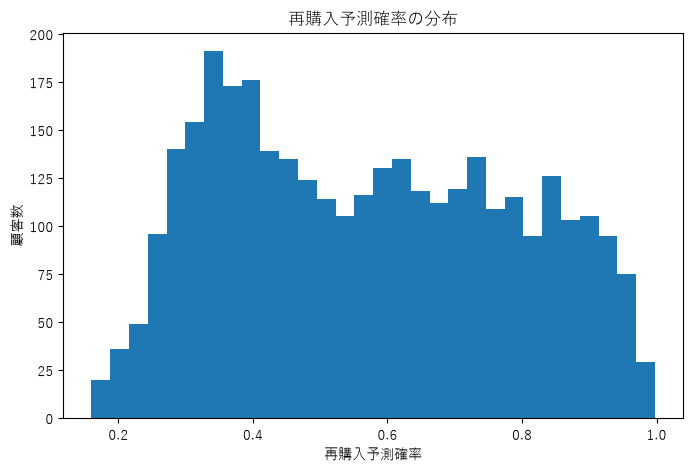

In [137]:
plt.figure(figsize=(8, 5))

plt.hist(
    model_df_extended["RepurchaseProbability"],
    bins=30
)

plt.xlabel("再購入予測確率")
plt.ylabel("顧客数")
plt.title("再購入予測確率の分布")

plt.show()

In [138]:
model_df_extended["ProbabilityGroup"] = pd.cut(
    model_df_extended["RepurchaseProbability"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[
        "0-20%",
        "20-40%",
        "40-60%",
        "60-80%",
        "80-100%"
    ],
    include_lowest=True
)

In [139]:
probability_summary = (
    model_df_extended
    .groupby(
        "ProbabilityGroup",
        observed=True
    )
    .agg(
        CustomerCount=(
            "CustomerID",
            "count"
        ),
        ActualRepurchaseRate=(
            "Repurchased",
            "mean"
        ),
        AvgPredictedProbability=(
            "RepurchaseProbability",
            "mean"
        )
    )
)

probability_summary[
    "ActualRepurchaseRate"
] *= 100

probability_summary[
    "AvgPredictedProbability"
] *= 100

probability_summary.round(1)

,CustomerCount,ActualRepurchaseRate,AvgPredictedProbability
ProbabilityGroup,,,
0-20%,37,21.6,18.4
20-40%,924,33.8,32.2
40-60%,900,49.0,49.4
60-80%,877,66.7,69.8
80-100%,632,91.0,88.5


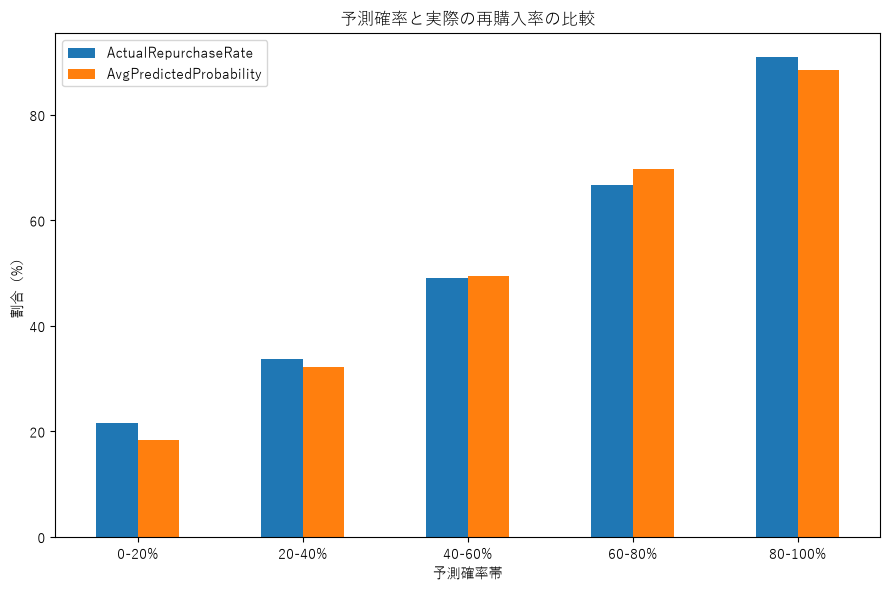

In [140]:
probability_summary[
    [
        "ActualRepurchaseRate",
        "AvgPredictedProbability"
    ]
].plot(
    kind="bar",
    figsize=(9, 6)
)

plt.xlabel("予測確率帯")
plt.ylabel("割合（%）")
plt.title("予測確率と実際の再購入率の比較")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [141]:
from sklearn.model_selection import cross_val_predict

oof_proba = cross_val_predict(
    final_logistic_model,
    x_final,
    y_final,
    cv=cv,
    method="predict_proba"
)[:, 1]

In [142]:
model_df_extended["OOF_RepurchaseProbability"] = (
    oof_proba
)

In [143]:
model_df_extended[
    [
        "CustomerID",
        "Repurchased",
        "RepurchaseProbability",
        "OOF_RepurchaseProbability"
    ]
].head()

,CustomerID,Repurchased,RepurchaseProbability,OOF_RepurchaseProbability
0,12346.0,0,0.206130,0.220663
1,12347.0,1,0.824421,0.823239
2,12348.0,1,0.582207,0.574042
3,12350.0,0,0.320490,0.316301
4,12352.0,1,0.691539,0.685046


In [144]:
model_df_extended["OOF_ProbabilityGroup"] = pd.cut(
    model_df_extended["OOF_RepurchaseProbability"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=[
        "0-20%",
        "20-40%",
        "40-60%",
        "60-80%",
        "80-100%"
    ],
    include_lowest=True
)

In [145]:
oof_probability_summary = (
    model_df_extended
    .groupby(
        "OOF_ProbabilityGroup",
        observed=True
    )
    .agg(
        CustomerCount=(
            "CustomerID",
            "count"
        ),
        ActualRepurchaseRate=(
            "Repurchased",
            "mean"
        ),
        AvgPredictedProbability=(
            "OOF_RepurchaseProbability",
            "mean"
        )
    )
)

oof_probability_summary[
    "ActualRepurchaseRate"
] *= 100

oof_probability_summary[
    "AvgPredictedProbability"
] *= 100

oof_probability_summary.round(1)

,CustomerCount,ActualRepurchaseRate,AvgPredictedProbability
OOF_ProbabilityGroup,,,
0-20%,40,20.0,18.4
20-40%,920,33.9,32.2
40-60%,903,49.4,49.5
60-80%,871,66.0,69.8
80-100%,636,91.2,88.5


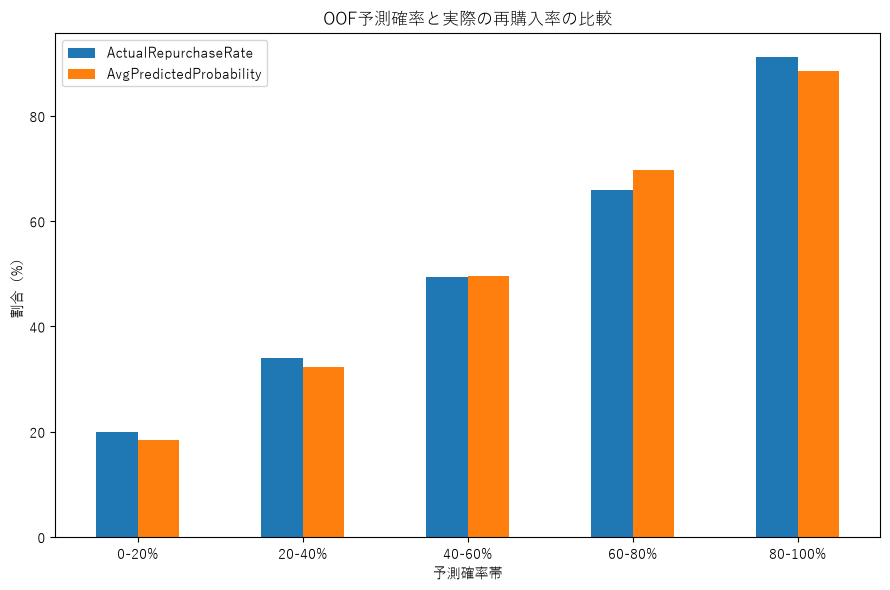

In [146]:
oof_probability_summary[
    [
        "ActualRepurchaseRate",
        "AvgPredictedProbability"
    ]
].plot(
    kind="bar",
    figsize=(9, 6)
)

plt.xlabel("予測確率帯")
plt.ylabel("割合（%）")
plt.title("OOF予測確率と実際の再購入率の比較")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [147]:
from sklearn.metrics import brier_score_loss

brier_score = brier_score_loss(
    y_final,
    oof_proba
)

print("Brier Score:", round(brier_score, 3))

Brier Score: 0.201


In [148]:
model_df_extended["R_score_cutoff"] = pd.qcut(
    model_df_extended["Recency"],
    3,
    labels=[3, 2, 1]
)

model_df_extended["F_score_cutoff"] = pd.qcut(
    model_df_extended["Frequency"].rank(method="first"),
    3,
    labels=[1, 2, 3]
)

In [149]:
segment_map_final = {
    (3, 3): "優良顧客",
    (3, 2): "優良候補",
    (3, 1): "新規顧客",

    (2, 3): "要フォロー",
    (2, 2): "継続停滞",
    (2, 1): "初回購入後停滞",

    (1, 3): "休眠優良顧客",
    (1, 2): "休眠顧客",
    (1, 1): "長期休眠顧客"
}

In [150]:
model_df_extended["Segment_cutoff"] = (
    model_df_extended.apply(
        lambda row: segment_map_final[
            (
                int(row["R_score_cutoff"]),
                int(row["F_score_cutoff"])
            )
        ],
        axis=1
    )
)

In [151]:
model_df_extended[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "R_score_cutoff",
        "F_score_cutoff",
        "Segment_cutoff"
    ]
].head()

,CustomerID,Recency,Frequency,R_score_cutoff,F_score_cutoff,Segment_cutoff
0,12346.0,234,1,1,1,長期休眠顧客
1,12347.0,38,5,3,3,優良顧客
2,12348.0,157,3,1,2,休眠顧客
3,12350.0,219,1,1,1,長期休眠顧客
4,12352.0,171,5,1,3,休眠優良顧客


In [152]:
segment_prediction_summary = (
    model_df_extended
    .groupby(
        "Segment_cutoff",
        observed=True
    )
    .agg(
        CustomerCount=(
            "CustomerID",
            "count"
        ),
        ActualRepurchaseRate=(
            "Repurchased",
            "mean"
        ),
        AvgOOFProbability=(
            "OOF_RepurchaseProbability",
            "mean"
        )
    )
)

segment_prediction_summary[
    "ActualRepurchaseRate"
] *= 100

segment_prediction_summary[
    "AvgOOFProbability"
] *= 100

segment_prediction_summary = (
    segment_prediction_summary
    .sort_values(
        "ActualRepurchaseRate",
        ascending=False
    )
)

segment_prediction_summary.round(1)

,CustomerCount,ActualRepurchaseRate,AvgOOFProbability
Segment_cutoff,,,
優良顧客,679,86.5,85.1
要フォロー,364,76.9,76.7
優良候補,292,59.6,62.6
休眠優良顧客,80,56.2,67.5
継続停滞,447,56.2,56.6
新規顧客,161,48.4,46.0
初回購入後停滞,307,44.6,40.7
休眠顧客,384,39.8,43.1
長期休眠顧客,656,32.9,32.0


In [153]:
segment_probability_table = pd.crosstab(
    model_df_extended["Segment_cutoff"],
    model_df_extended["OOF_ProbabilityGroup"]
)

segment_probability_table

OOF_ProbabilityGroup,0-20%,20-40%,40-60%,60-80%,80-100%
Segment_cutoff,,,,,
休眠優良顧客,0,0,12,60,8
休眠顧客,6,165,183,30,0
優良候補,0,7,89,195,1
優良顧客,0,0,5,172,502
初回購入後停滞,0,131,174,2,0
新規顧客,0,30,126,5,0
継続停滞,0,39,228,180,0
要フォロー,0,0,12,227,125
長期休眠顧客,34,548,74,0,0


In [154]:
segment_probability_ratio = pd.crosstab(
    model_df_extended["Segment_cutoff"],
    model_df_extended["OOF_ProbabilityGroup"],
    normalize="index"
).mul(100).round(1)

segment_probability_ratio

OOF_ProbabilityGroup,0-20%,20-40%,40-60%,60-80%,80-100%
Segment_cutoff,,,,,
休眠優良顧客,0.0,0.0,15.0,75.0,10.0
休眠顧客,1.6,43.0,47.7,7.8,0.0
優良候補,0.0,2.4,30.5,66.8,0.3
優良顧客,0.0,0.0,0.7,25.3,73.9
初回購入後停滞,0.0,42.7,56.7,0.7,0.0
新規顧客,0.0,18.6,78.3,3.1,0.0
継続停滞,0.0,8.7,51.0,40.3,0.0
要フォロー,0.0,0.0,3.3,62.4,34.3
長期休眠顧客,5.2,83.5,11.3,0.0,0.0


In [155]:
segment_probability_detail = (
    model_df_extended
    .groupby(
        [
            "Segment_cutoff",
            "OOF_ProbabilityGroup"
        ],
        observed=True
    )
    .agg(
        CustomerCount=(
            "CustomerID",
            "count"
        ),
        ActualRepurchaseRate=(
            "Repurchased",
            "mean"
        ),
        AvgOOFProbability=(
            "OOF_RepurchaseProbability",
            "mean"
        )
    )
    .reset_index()
)

In [156]:
segment_probability_detail[
    "ActualRepurchaseRate"
] *= 100

segment_probability_detail[
    "AvgOOFProbability"
] *= 100

In [157]:
segment_probability_detail.round(1)

,Segment_cutoff,OOF_ProbabilityGroup,CustomerCount,ActualRepurchaseRate,AvgOOFProbability
0,休眠優良顧客,40-60%,12,50.0,52.8
1,休眠優良顧客,60-80%,60,60.0,68.0
2,休眠優良顧客,80-100%,8,37.5,85.4
3,休眠顧客,0-20%,6,0.0,18.1
4,休眠顧客,20-40%,165,32.1,32.2
5,休眠顧客,40-60%,183,44.3,50.2
6,休眠顧客,60-80%,30,63.3,64.5
7,優良候補,20-40%,7,42.9,33.5
8,優良候補,40-60%,89,58.4,53.4
9,優良候補,60-80%,195,60.5,67.7


In [158]:
target_segments = [
    "継続停滞",
    "休眠顧客",
    "初回購入後停滞"
]

segment_probability_detail[
    segment_probability_detail[
        "Segment_cutoff"
    ].isin(target_segments)
].round(1)

,Segment_cutoff,OOF_ProbabilityGroup,CustomerCount,ActualRepurchaseRate,AvgOOFProbability
3,休眠顧客,0-20%,6,0.0,18.1
4,休眠顧客,20-40%,165,32.1,32.2
5,休眠顧客,40-60%,183,44.3,50.2
6,休眠顧客,60-80%,30,63.3,64.5
14,初回購入後停滞,20-40%,131,42.7,34.3
15,初回購入後停滞,40-60%,174,46.0,45.3
16,初回購入後停滞,60-80%,2,50.0,62.1
20,継続停滞,20-40%,39,28.2,35.3
21,継続停滞,40-60%,228,53.9,52.8
22,継続停滞,60-80%,180,65.0,66.1


In [159]:
target_segments = [
    "休眠顧客",
    "継続停滞",
    "初回購入後停滞"
]

target_customers = model_df_extended[
    (model_df_extended["Segment_cutoff"].isin(target_segments))
    & (model_df_extended["OOF_RepurchaseProbability"] >= 0.4)
].copy()

In [160]:
target_customers.groupby(
    "Segment_cutoff",
    observed=True
).agg(
    CustomerCount=("CustomerID", "count"),
    AvgOOFProbability=("OOF_RepurchaseProbability", "mean"),
    ActualRepurchaseRate=("Repurchased", "mean"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean")
).round(2)

,CustomerCount,AvgOOFProbability,ActualRepurchaseRate,AvgRecency,AvgFrequency,AvgMonetary
Segment_cutoff,,,,,,
休眠顧客,213,0.52,0.47,164.77,2.10,806.89
初回購入後停滞,176,0.45,0.46,74.95,1.00,507.95
継続停滞,408,0.59,0.59,75.79,2.16,880.83


In [161]:
target_customers["TargetPriority"] = pd.cut(
    target_customers["OOF_RepurchaseProbability"],
    bins=[0.4, 0.6, 1.0],
    labels=[
        "中確率（40-60%）",
        "高確率（60%以上）"
    ],
    include_lowest=True
)

In [162]:
priority_summary = (
    target_customers
    .groupby(
        ["Segment_cutoff", "TargetPriority"],
        observed=True
    )
    .agg(
        CustomerCount=("CustomerID", "count"),
        AvgProbability=("OOF_RepurchaseProbability", "mean"),
        ActualRepurchaseRate=("Repurchased", "mean"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean")
    )
)

priority_summary.round(2)

CustomerCount  AvgProbability  \
Segment_cutoff TargetPriority                                  
休眠顧客           中確率（40-60%）               183            0.50   
               高確率（60%以上）                 30            0.64   
初回購入後停滞        中確率（40-60%）               174            0.45   
               高確率（60%以上）                  2            0.62   
継続停滞           中確率（40-60%）               228            0.53   
               高確率（60%以上）                180            0.66   

                               ActualRepurchaseRate  AvgRecency  AvgFrequency  \
Segment_cutoff TargetPriority                                                   
休眠顧客           中確率（40-60%）                     0.44      166.91          2.02   
               高確率（60%以上）                      0.63      151.73          2.60   
初回購入後停滞        中確率（40-60%）                     0.46       75.26          1.00   
               高確率（60%以上）                      0.50       47.50          1.00   
継続停滞           中確率（40-60%）                     0.54       80.17          1.94   
               高確率（60%以上）                      0.65       70.24          2.45   

                               AvgMonetary  
Segment_cutoff TargetPriority               
休眠顧客           中確率（40-60%）          655.79  
               高確率（60%以上）          1728.56  
初回購入後停滞        中確率（40-60%）          488.08  
               高確率（60%以上）          2236.22  
継続停滞           中確率（40-60%）          690.49  
               高確率（60%以上）          1121.92

In [163]:
segment_baseline = (
    model_df_extended
    .groupby(
        "Segment_cutoff",
        observed=True
    )
    .agg(
        SegmentCustomerCount=(
            "CustomerID",
            "count"
        ),
        SegmentRepurchaseRate=(
            "Repurchased",
            "mean"
        )
    )
    .reset_index()
)

In [164]:
high_probability_customers = model_df_extended[
    (
        model_df_extended["Segment_cutoff"]
        .isin([
            "休眠顧客",
            "継続停滞",
            "初回購入後停滞"
        ])
    )
    &
    (
        model_df_extended["OOF_RepurchaseProbability"] >= 0.6
    )
]

In [165]:
high_probability_summary = (
    high_probability_customers
    .groupby(
        "Segment_cutoff",
        observed=True
    )
    .agg(
        HighProbabilityCount=(
            "CustomerID",
            "count"
        ),
        HighProbabilityRepurchaseRate=(
            "Repurchased",
            "mean"
        )
    )
    .reset_index()
)

In [166]:
targeting_effect = segment_baseline.merge(
    high_probability_summary,
    on="Segment_cutoff",
    how="inner"
)

In [167]:
targeting_effect[
    "SegmentRepurchaseRate"
] *= 100

targeting_effect[
    "HighProbabilityRepurchaseRate"
] *= 100

In [168]:
targeting_effect["ImprovementPoint"] = (
    targeting_effect[
        "HighProbabilityRepurchaseRate"
    ]
    -
    targeting_effect[
        "SegmentRepurchaseRate"
    ]
)

In [169]:
targeting_effect["Lift"] = (
    targeting_effect[
        "HighProbabilityRepurchaseRate"
    ]
    /
    targeting_effect[
        "SegmentRepurchaseRate"
    ]
)

In [170]:
targeting_effect.round(2)

,Segment_cutoff,SegmentCustomerCount,SegmentRepurchaseRate,HighProbabilityCount,HighProbabilityRepurchaseRate,ImprovementPoint,Lift
0,休眠顧客,384,39.84,30,63.33,23.49,1.59
1,初回購入後停滞,307,44.63,2,50.00,5.37,1.12
2,継続停滞,447,56.15,180,65.00,8.85,1.16


In [171]:
targeting_effect["TargetRate"] = (
    targeting_effect["HighProbabilityCount"]
    / targeting_effect["SegmentCustomerCount"]
    * 100
)

In [172]:
high_probability_actual = (
    high_probability_customers
    .groupby(
        "Segment_cutoff",
        observed=True
    )["Repurchased"]
    .sum()
    .reset_index(
        name="CapturedRepurchasers"
    )
)

In [173]:
segment_actual = (
    model_df_extended
    .groupby(
        "Segment_cutoff",
        observed=True
    )["Repurchased"]
    .sum()
    .reset_index(
        name="TotalRepurchasers"
    )
)

In [174]:
targeting_effect = targeting_effect.merge(
    high_probability_actual,
    on="Segment_cutoff",
    how="left"
)

targeting_effect = targeting_effect.merge(
    segment_actual,
    on="Segment_cutoff",
    how="left"
)

In [175]:
targeting_effect["CaptureRate"] = (
    targeting_effect["CapturedRepurchasers"]
    / targeting_effect["TotalRepurchasers"]
    * 100
)

In [176]:
targeting_effect[
    [
        "Segment_cutoff",
        "SegmentCustomerCount",
        "HighProbabilityCount",
        "TargetRate",
        "SegmentRepurchaseRate",
        "HighProbabilityRepurchaseRate",
        "ImprovementPoint",
        "Lift",
        "CapturedRepurchasers",
        "TotalRepurchasers",
        "CaptureRate"
    ]
].round(2)

,Segment_cutoff,SegmentCustomerCount,HighProbabilityCount,TargetRate,SegmentRepurchaseRate,HighProbabilityRepurchaseRate,ImprovementPoint,Lift,CapturedRepurchasers,TotalRepurchasers,CaptureRate
0,休眠顧客,384,30,7.81,39.84,63.33,23.49,1.59,19,153,12.42
1,初回購入後停滞,307,2,0.65,44.63,50.00,5.37,1.12,1,137,0.73
2,継続停滞,447,180,40.27,56.15,65.00,8.85,1.16,117,251,46.61


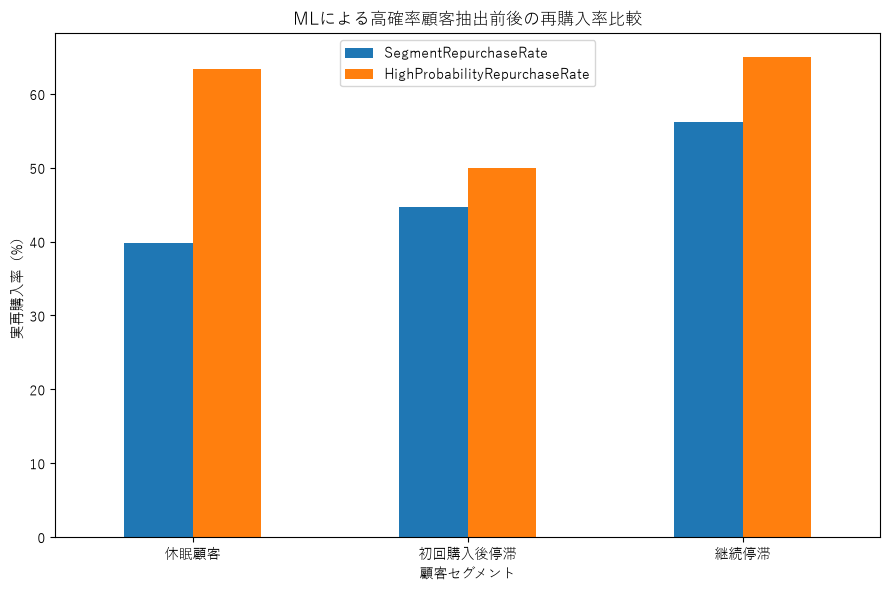

In [177]:
targeting_plot = targeting_effect.set_index(
    "Segment_cutoff"
)[
    [
        "SegmentRepurchaseRate",
        "HighProbabilityRepurchaseRate"
    ]
]

targeting_plot.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.ylabel("実再購入率（%）")
plt.xlabel("顧客セグメント")
plt.title("MLによる高確率顧客抽出前後の再購入率比較")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [178]:
action_summary = pd.DataFrame({
    "Segment": [
        "休眠顧客",
        "継続停滞",
        "初回購入後停滞"
    ],
    "RecommendedAction": [
        "高確率層を優先して再活性化施策",
        "高確率層を中心に再購入促進施策",
        "今回のモデルでは優先対象としない"
    ],
    "Reason": [
        "対象率7.81%でLift1.59と効率が高い",
        "対象率40.27%で再購入者の46.61%を捕捉",
        "高確率顧客が2人のみで実用性が低い"
    ]
})

action_summary

,Segment,RecommendedAction,Reason
0,休眠顧客,高確率層を優先して再活性化施策,対象率7.81%でLift1.59と効率が高い
1,継続停滞,高確率層を中心に再購入促進施策,対象率40.27%で再購入者の46.61%を捕捉
2,初回購入後停滞,今回のモデルでは優先対象としない,高確率顧客が2人のみで実用性が低い


RFMセグメントと再購入予測を組み合わせた結果、休眠顧客では全体の7.81%に対象を絞ることで再購入率が39.84%から63.33%へ上昇し、Liftは1.59となった。一方、継続停滞顧客では40.27%を対象とすることで、実際の再購入者の46.61%を捕捉できた。このため、休眠顧客は効率重視、継続停滞顧客はカバー率重視のターゲティング候補と考えられる。初回購入後停滞顧客では高確率顧客が2人にとどまり、今回のモデルによる細分化の実用性は限定的だった。  
なお再購入確率が高いことは「施策を打てば再購入する」ことを意味しない。

# 分析結果まとめ

### 1.RFM分析  
顧客をRecencyとFrequencyに基づく9セグメントに分類した。優良顧客が約20％存在する一方、一度購入した後に継続購入していない顧客も多く、再購入促進が重要な課題であることが分かった。  
### 2.再購入予測  
基準日以前の購買履歴から90日以内の再購入を予測した。Logistic RegressionとRandom Forestを比較した結果、Logistic Regressionのほうが高いROC-AUCと安定性を示した。  
### 3.特徴量エンジニアリング  
RFMに加えて商品種類数、購入日数、顧客期間、平均注文金額を検証した結果、UniqueProductsのみが安定した性能改善を示し、最終的にRecency、Frequency、Monetary、UniqueProductsを採用した。  
### 4.最終モデル  
5-fold CVにおける最終Logistic RegressionのROC-AUCは0.746であった。モデル係数では、Frequencyの寄与が最も大きく、UniqueProductsが続き、Recencyは負の関連を示した。Monetaryの独立した寄与は小さかった。  
### 5.ターゲティング  
RFMと再購入予測を組み合わせることで同一セグメント内でも顧客を細分化できた。特に休眠顧客では、全体の7.81％に対象を絞ることで実再購入率が39.84％から63.33％に上昇し、Lift 1.59となった。継続停滞顧客では対象率40.27％で再購入者の46.61％を捕捉できた。  

# 分析上の限界

・UCI Online Retailという単一データセットである  
・観測期間以前の顧客履歴は分からない  
・90日という再購入期間は分析者が設定したもの  
・特徴量・モデル選択と評価に同一データを用いている  
・再購入予測は施策による因果効果を意味しない  
・価格・商品カテゴリ・国・季節性などを十分利用していない  